In [1]:
import sys
import subprocess
import pandas as pd
import numpy as np
import requests
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine
import tweepy
import openai
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import xgboost as xgb
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import streamlit as st

# Step 0: Connecting to SQL Database

In [2]:
# Verify Database and proper tokens exist in .env file
from dotenv import load_dotenv

load_dotenv()

print("Database URL found:", os.getenv("DATABASE_URL") is not None)
print("Twitter token found:", os.getenv("X_BEARER_TOKEN") is not None)

Database URL found: True
Twitter token found: True


In [3]:
# Connect to the database and run a simple query to verify connection
from sqlalchemy import create_engine, text

engine = create_engine(os.getenv("DATABASE_URL"))

with engine.connect() as conn:
    result = conn.execute(
        text("SELECT current_database(), current_user")
    )
    
    print(result.fetchone())

('twitter_engagement', 'postgres')


In [4]:
# Verify tables exist in the database
query = """
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'public'
ORDER BY table_name
"""

with engine.connect() as conn:
    result = conn.execute(text(query))

    for row in result:
        print(row[0])

tweet_labels
tweet_media
tweets
users


# Step 1: Getting Twitter Data

In [5]:
import os
import re
import json
import pandas as pd
import tweepy

from dotenv import load_dotenv
from sqlalchemy import create_engine, text

load_dotenv()

engine = create_engine(os.getenv("DATABASE_URL"))

client = tweepy.Client(
    bearer_token=os.getenv("X_BEARER_TOKEN"),
    wait_on_rate_limit=True
)

print("Setup complete")

Setup complete


In [6]:
# Text cleaning function
def clean_tweet_text(text):
    if text is None:
        return None
    
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "@USER", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"\s+", " ", text)
    
    return text.strip()

In [10]:
# Defining time windows and test queries for data collection
from datetime import datetime, timedelta, timezone
import pandas as pd

now = datetime.now(timezone.utc)

# Each tuple is: (start_days_ago, end_days_ago)
# Example: 7.0 to 6.8 days ago means older tweets with time to gain engagement.
time_windows = [
    (7.0, 6.8),
    (6.8, 6.6),
    (6.6, 6.4),
    (6.4, 6.2),
    (6.2, 6.0)
]

test_queries = {
    "broad_general": '("the" OR "this" OR "you" OR "that" OR "with") lang:en -is:retweet',
    "questions": '("why" OR "how" OR "what" OR "when" OR "where") lang:en -is:retweet',
    "opinions": '("best" OR "worst" OR "favorite" OR "overrated" OR "underrated") lang:en -is:retweet',
    "entertainment": '("movie" OR "music" OR "game" OR "show" OR "book") lang:en -is:retweet',
    "life_topics": '("food" OR "travel" OR "work" OR "school" OR "fitness") lang:en -is:retweet'
}


In [11]:
# Test collection
all_responses = []

for query_name, query_text in test_queries.items():
    for start_days, end_days in time_windows:
        start_time = now - timedelta(days=start_days)
        end_time = now - timedelta(days=end_days)

        start_time_str = start_time.isoformat(timespec="seconds").replace("+00:00", "Z")
        end_time_str = end_time.isoformat(timespec="seconds").replace("+00:00", "Z")

        response = client.search_recent_tweets(
            query=query_text,
            max_results=10,
            start_time=start_time_str,
            end_time=end_time_str,
            sort_order="relevancy",
            tweet_fields=[
                "created_at",
                "author_id",
                "lang",
                "public_metrics",
                "entities",
                "attachments",
                "referenced_tweets"
            ],
            expansions=[
                "attachments.media_keys",
                "author_id",
                "referenced_tweets.id"
            ],
            media_fields=[
                "media_key",
                "type",
                "url",
                "preview_image_url",
                "alt_text",
                "width",
                "height",
                "duration_ms",
                "public_metrics"
            ],
            user_fields=[
                "username",
                "name",
                "verified",
                "public_metrics"
            ]
        )

        tweet_count = 0 if response.data is None else len(response.data)

        print(
            f"{query_name} | {start_time_str} to {end_time_str} | tweets returned: {tweet_count}"
        )

        all_responses.append({
            "query_name": query_name,
            "query_text": query_text,
            "start_time": start_time_str,
            "end_time": end_time_str,
            "response": response,
            "tweet_count": tweet_count
        })

print("Total API calls made:", len(all_responses))
print("Total tweets returned before deduping:", sum(r["tweet_count"] for r in all_responses))

broad_general | 2026-06-04T18:59:35Z to 2026-06-04T23:47:35Z | tweets returned: 10
broad_general | 2026-06-04T23:47:35Z to 2026-06-05T04:35:35Z | tweets returned: 10
broad_general | 2026-06-05T04:35:35Z to 2026-06-05T09:23:35Z | tweets returned: 10
broad_general | 2026-06-05T09:23:35Z to 2026-06-05T14:11:35Z | tweets returned: 10
broad_general | 2026-06-05T14:11:35Z to 2026-06-05T18:59:35Z | tweets returned: 10
questions | 2026-06-04T18:59:35Z to 2026-06-04T23:47:35Z | tweets returned: 10
questions | 2026-06-04T23:47:35Z to 2026-06-05T04:35:35Z | tweets returned: 9
questions | 2026-06-05T04:35:35Z to 2026-06-05T09:23:35Z | tweets returned: 10
questions | 2026-06-05T09:23:35Z to 2026-06-05T14:11:35Z | tweets returned: 10
questions | 2026-06-05T14:11:35Z to 2026-06-05T18:59:35Z | tweets returned: 10
opinions | 2026-06-04T18:59:35Z to 2026-06-04T23:47:35Z | tweets returned: 10
opinions | 2026-06-04T23:47:35Z to 2026-06-05T04:35:35Z | tweets returned: 9
opinions | 2026-06-05T04:35:35Z to 2

In [12]:
# Vareity check

test_rows = []

for item in all_responses:
    response = item["response"]

    for tweet in response.data or []:
        metrics = tweet.public_metrics or {}

        test_rows.append({
            "tweet_id": str(tweet.id),
            "query_name": item["query_name"],
            "start_time_window": item["start_time"],
            "end_time_window": item["end_time"],
            "created_at": tweet.created_at,
            "text": tweet.text,
            "like_count": metrics.get("like_count", 0),
            "reply_count": metrics.get("reply_count", 0),
            "retweet_count": metrics.get("retweet_count", 0),
            "quote_count": metrics.get("quote_count", 0),
        })

test_df = pd.DataFrame(test_rows)

test_df["engagement_total"] = (
    test_df["like_count"] +
    test_df["reply_count"] +
    test_df["retweet_count"] +
    test_df["quote_count"]
)

test_df = test_df.drop_duplicates(subset="tweet_id")

print("Unique tweets:", len(test_df))
print("Unique queries represented:", test_df["query_name"].nunique())
print("Created_at range:", test_df["created_at"].min(), "to", test_df["created_at"].max())

display(
    test_df[[
        "query_name",
        "created_at",
        "like_count",
        "reply_count",
        "retweet_count",
        "quote_count",
        "engagement_total",
        "text"
    ]]
    .sort_values("engagement_total", ascending=False)
    .head(25)
)

Unique tweets: 243
Unique queries represented: 5
Created_at range: 2026-06-04 19:00:30+00:00 to 2026-06-05 18:44:39+00:00


,query_name,created_at,like_count,reply_count,retweet_count,quote_count,engagement_total,text
169,entertainment,2026-06-05 08:18:54+00:00,2798,40,367,16,3221,In the Game Boy Color educational game Blue's ...
198,life_topics,2026-06-04 19:17:15+00:00,599,221,47,249,1116,What fast food spot did you work at? I worked ...
192,entertainment,2026-06-05 18:32:07+00:00,647,7,10,0,664,My favorite Bond book is Moonraker for this ve...
203,life_topics,2026-06-04 21:25:26+00:00,326,37,99,6,468,Connecticut is spending millions of your tax m...
34,broad_general,2026-06-05 12:55:49+00:00,308,4,129,12,453,𝙐𝙉𝘿𝙀𝙍 𝙏𝙃𝙀 𝙈𝙊𝙊𝙉 𝘼𝙉𝘿 𝙎𝙏𝘼𝙍𝙎 🌙✨\n\n𝙎𝙤𝙢𝙚 𝙣𝙞𝙜𝙝𝙩𝙨 𝙚𝙣𝙙...
28,broad_general,2026-06-05 04:35:36+00:00,343,39,19,1,402,In bear markets you absolutely just do not buy...
208,life_topics,2026-06-05 03:32:16+00:00,297,25,10,0,332,The worst form of fitness is when you start th...
145,opinions,2026-06-05 14:14:32+00:00,222,28,13,20,283,Who’s the most overrated / underrated Monarch ...
48,broad_general,2026-06-05 14:44:05+00:00,235,30,5,1,271,@PhiloGroves Let me explain why this happens. ...
78,questions,2026-06-05 08:00:01+00:00,126,139,2,1,268,i think people often confuse performance with ...


In [13]:
# DataFrame creation from multiple query/time-window responses

tweet_rows = []
media_rows = []
user_rows = []

for item in all_responses:
    response = item["response"]
    query_name = item["query_name"]
    query_text = item["query_text"]
    start_time_window = item["start_time"]
    end_time_window = item["end_time"]

    tweets = response.data or []
    includes = response.includes or {}

    media_lookup = {
        media.data["media_key"]: media
        for media in includes.get("media", [])
    }

    # users
    for user in includes.get("users", []):
        metrics = user.data.get("public_metrics", {})

        user_rows.append({
            "author_id": str(user.id),
            "username": user.data.get("username"),
            "name": user.data.get("name"),
            "verified": user.data.get("verified"),
            "followers_count": metrics.get("followers_count", 0),
            "following_count": metrics.get("following_count", 0),
            "tweet_count": metrics.get("tweet_count", 0),
            "listed_count": metrics.get("listed_count", 0),
            "raw_json": json.dumps(user.data)
        })

    # tweets and media
    for tweet in tweets:
        metrics = tweet.public_metrics or {}
        attachments = tweet.data.get("attachments", {})
        media_keys = attachments.get("media_keys", [])

        tweet_rows.append({
            "tweet_id": str(tweet.id),
            "author_id": str(tweet.author_id),
            "created_at": tweet.created_at,
            "text": tweet.text,
            "clean_text": clean_tweet_text(tweet.text),
            "lang": tweet.lang,

            "retweet_count": metrics.get("retweet_count", 0),
            "reply_count": metrics.get("reply_count", 0),
            "like_count": metrics.get("like_count", 0),
            "quote_count": metrics.get("quote_count", 0),

            "has_media": len(media_keys) > 0,
            "media_count": len(media_keys),

            "collection_source": query_name,
            "search_query": query_text,

            # useful for testing; not currently in your database unless you add columns
            "start_time_window": start_time_window,
            "end_time_window": end_time_window,

            "raw_json": json.dumps(tweet.data)
        })

        for media_key in media_keys:
            media = media_lookup.get(media_key)

            if media is None:
                continue

            media_rows.append({
                "media_key": media_key,
                "tweet_id": str(tweet.id),
                "media_type": media.data.get("type"),
                "url": media.data.get("url"),
                "preview_image_url": media.data.get("preview_image_url"),
                "alt_text": media.data.get("alt_text"),
                "width": media.data.get("width"),
                "height": media.data.get("height"),
                "duration_ms": media.data.get("duration_ms"),
                "public_metrics": json.dumps(media.data.get("public_metrics", {})),
                "raw_json": json.dumps(media.data)
            })

tweets_df = pd.DataFrame(tweet_rows)
media_df = pd.DataFrame(media_rows)
users_df = pd.DataFrame(user_rows)

# Deduplicate
if len(tweets_df) > 0:
    tweets_df = tweets_df.drop_duplicates(subset="tweet_id").copy()

if len(media_df) > 0:
    media_df = media_df.drop_duplicates(subset="media_key").copy()

if len(users_df) > 0:
    users_df = users_df.drop_duplicates(subset="author_id").copy()

# Engagement features
if len(tweets_df) > 0:
    tweets_df["engagement_total"] = (
        tweets_df["like_count"] +
        tweets_df["reply_count"] +
        tweets_df["retweet_count"] +
        tweets_df["quote_count"]
    )

    tweets_df = tweets_df.sort_values(by="engagement_total", ascending=False)



tweets_df["eligible_for_labeling"] = (
    tweets_df["engagement_total"] >= 2
)

# Propagate eligible_for_labeling to media_df and users_df
tweet_eligibility_lookup = (
    tweets_df
    .set_index("tweet_id")["eligible_for_labeling"]
    .to_dict()
)

user_eligibility_lookup = (
    tweets_df
    .groupby("author_id")["eligible_for_labeling"]
    .any()
    .to_dict()
)

if len(media_df) > 0:
    media_df["eligible_for_labeling"] = (
        media_df["tweet_id"]
        .map(tweet_eligibility_lookup)
        .fillna(False)
    )
else:
    media_df["eligible_for_labeling"] = pd.Series(dtype=bool)

if len(users_df) > 0:
    users_df["eligible_for_labeling"] = (
        users_df["author_id"]
        .map(user_eligibility_lookup)
        .fillna(False)
    )
else:
    users_df["eligible_for_labeling"] = pd.Series(dtype=bool)

display(tweets_df.head())
display(media_df.head())
display(users_df.head())

,tweet_id,author_id,created_at,text,clean_text,lang,retweet_count,reply_count,like_count,quote_count,has_media,media_count,collection_source,search_query,start_time_window,end_time_window,raw_json,engagement_total,eligible_for_labeling
169,2062811385613156799,1805986061467951104,2026-06-05 08:18:54+00:00,In the Game Boy Color educational game Blue's ...,In the Game Boy Color educational game Blue's ...,en,367,40,2798,16,True,1,entertainment,"(""movie"" OR ""music"" OR ""game"" OR ""show"" OR ""bo...",2026-06-05T04:35:35Z,2026-06-05T09:23:35Z,"{""entities"": {""urls"": [{""start"": 222, ""end"": 2...",3221,True
198,2062614676660187382,94844786,2026-06-04 19:17:15+00:00,What fast food spot did you work at? I worked ...,What fast food spot did you work at? I worked ...,en,47,221,599,249,False,0,life_topics,"(""food"" OR ""travel"" OR ""work"" OR ""school"" OR ""...",2026-06-04T18:59:35Z,2026-06-04T23:47:35Z,"{""author_id"": ""94844786"", ""edit_history_tweet_...",1116,True
192,2062965706996723879,1668704081102389249,2026-06-05 18:32:07+00:00,My favorite Bond book is Moonraker for this ve...,My favorite Bond book is Moonraker for this ve...,en,10,7,647,0,False,0,entertainment,"(""movie"" OR ""music"" OR ""game"" OR ""show"" OR ""bo...",2026-06-05T14:11:35Z,2026-06-05T18:59:35Z,"{""author_id"": ""1668704081102389249"", ""edit_his...",664,True
203,2062646937158140250,62812958,2026-06-04 21:25:26+00:00,Connecticut is spending millions of your tax m...,Connecticut is spending millions of your tax m...,en,99,37,326,6,False,0,life_topics,"(""food"" OR ""travel"" OR ""work"" OR ""school"" OR ""...",2026-06-04T18:59:35Z,2026-06-04T23:47:35Z,"{""author_id"": ""62812958"", ""edit_history_tweet_...",468,True
34,2062881075488338317,1979572602617331712,2026-06-05 12:55:49+00:00,𝙐𝙉𝘿𝙀𝙍 𝙏𝙃𝙀 𝙈𝙊𝙊𝙉 𝘼𝙉𝘿 𝙎𝙏𝘼𝙍𝙎 🌙✨\n\n𝙎𝙤𝙢𝙚 𝙣𝙞𝙜𝙝𝙩𝙨 𝙚𝙣𝙙...,"𝙐𝙉𝘿𝙀𝙍 𝙏𝙃𝙀 𝙈𝙊𝙊𝙉 𝘼𝙉𝘿 𝙎𝙏𝘼𝙍𝙎 🌙✨ 𝙎𝙤𝙢𝙚 𝙣𝙞𝙜𝙝𝙩𝙨 𝙚𝙣𝙙, 𝙗...",en,129,4,308,12,True,1,broad_general,"(""the"" OR ""this"" OR ""you"" OR ""that"" OR ""with"")...",2026-06-05T09:23:35Z,2026-06-05T14:11:35Z,"{""text"": ""\ud835\ude50\ud835\ude49\ud835\ude3f...",453,True


,media_key,tweet_id,media_type,url,preview_image_url,alt_text,width,height,duration_ms,public_metrics,raw_json,eligible_for_labeling
0,3_2062636441377648640,2062636444473024953,photo,https://pbs.twimg.com/media/HJ_06kUXMAAxyFk.jpg,NaN,NaN,500,587,NaN,{},"{""media_key"": ""3_2062636441377648640"", ""type"":...",True
1,13_2062641289586147328,2062641777677353293,video,NaN,https://pbs.twimg.com/amplify_video_thumb/2062...,NaN,1080,1920,244266.0,"{""view_count"": 3248}","{""media_key"": ""13_2062641289586147328"", ""durat...",True
2,3_2062638641743347712,2062638653260861656,photo,https://pbs.twimg.com/media/HJ_26pUbQAASie6.jpg,NaN,NaN,1983,793,NaN,{},"{""media_key"": ""3_2062638641743347712"", ""type"":...",True
3,16_2062746391919898624,2062746399603638661,animated_gif,NaN,https://pbs.twimg.com/tweet_video_thumb/HKBY6i...,NaN,320,480,NaN,{},"{""media_key"": ""16_2062746391919898624"", ""width...",True
4,3_2062701456998682624,2062701464888471953,photo,https://pbs.twimg.com/media/HKAwC-YWUAATsTN.jpg,NaN,NaN,1728,1152,NaN,{},"{""media_key"": ""3_2062701456998682624"", ""width""...",True


,author_id,username,name,verified,followers_count,following_count,tweet_count,listed_count,raw_json,eligible_for_labeling
0,1214757469785747457,ripchillpill,Chill Pill 🔮 (Bald),False,97455,8973,329515,1849,"{""username"": ""ripchillpill"", ""name"": ""Chill Pi...",True
1,1503515073293303811,OT5DTour,OT5 Daily Tour,False,6085,10,28061,45,"{""username"": ""OT5DTour"", ""name"": ""OT5 Daily To...",True
2,1748811596711739393,M_O_Gwhy,𓊈 Mₐₗₐcₕᵢ Mᵤₛₜ Dᵢₑ♱𓊉,False,643,440,16129,9,"{""username"": ""M_O_Gwhy"", ""name"": ""\ud80c\ude88...",False
3,1778705111730049024,MatthewBac60261,Matt Do unto others.....,False,6064,7502,113769,7,"{""username"": ""MatthewBac60261"", ""name"": ""Matt ...",True
4,1351882364838944768,Damon22l,Damon,False,27593,443,334328,94,"{""username"": ""Damon22l"", ""name"": ""Damon"", ""id""...",True


engagement_total    39.699588
dtype: float64
243
count     243.000000
mean       39.699588
std       229.947057
min         0.000000
25%         0.000000
50%         1.000000
75%         5.500000
max      3221.000000
Name: engagement_total, dtype: float64


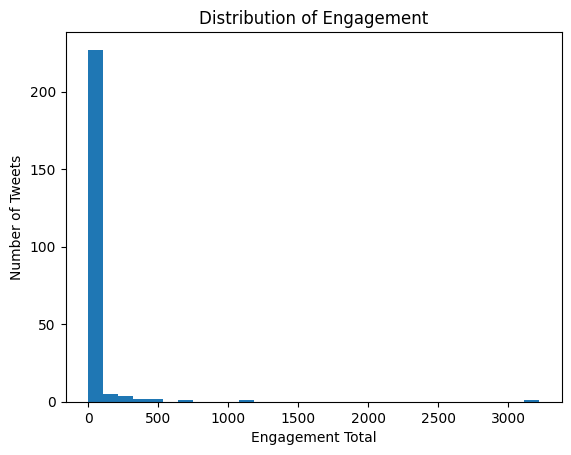

In [14]:

print(tweets_df[['engagement_total']].mean())
print(len(tweets_df))
print(tweets_df["engagement_total"].describe())

import matplotlib.pyplot as plt

plt.hist(tweets_df["engagement_total"], bins=30)
plt.xlabel("Engagement Total")
plt.ylabel("Number of Tweets")
plt.title("Distribution of Engagement")
plt.show()

In [15]:
print("Tweets:", len(tweets_df))
print("Media:", len(media_df))
print("Users:", len(users_df))

print("Duplicate tweets:", tweets_df["tweet_id"].duplicated().sum())
print("Duplicate media:", media_df["media_key"].duplicated().sum() if len(media_df) > 0 else 0)
print("Duplicate users:", users_df["author_id"].duplicated().sum() if len(users_df) > 0 else 0)

print(tweets_df["engagement_total"].describe())

Tweets: 243
Media: 94
Users: 231
Duplicate tweets: 0
Duplicate media: 0
Duplicate users: 0
count     243.000000
mean       39.699588
std       229.947057
min         0.000000
25%         0.000000
50%         1.000000
75%         5.500000
max      3221.000000
Name: engagement_total, dtype: float64


In [16]:
# Verifying correct data structure before SQL insertion
print("tweets_df:", tweets_df.shape)
print("media_df:", media_df.shape)
print("users_df:", users_df.shape)

print("Tweet columns:")
print(tweets_df.columns.tolist())

print("Media columns:")
print(media_df.columns.tolist())

print("User columns:")
print(users_df.columns.tolist())

tweets_df: (243, 19)
media_df: (94, 12)
users_df: (231, 10)
Tweet columns:
['tweet_id', 'author_id', 'created_at', 'text', 'clean_text', 'lang', 'retweet_count', 'reply_count', 'like_count', 'quote_count', 'has_media', 'media_count', 'collection_source', 'search_query', 'start_time_window', 'end_time_window', 'raw_json', 'engagement_total', 'eligible_for_labeling']
Media columns:
['media_key', 'tweet_id', 'media_type', 'url', 'preview_image_url', 'alt_text', 'width', 'height', 'duration_ms', 'public_metrics', 'raw_json', 'eligible_for_labeling']
User columns:
['author_id', 'username', 'name', 'verified', 'followers_count', 'following_count', 'tweet_count', 'listed_count', 'raw_json', 'eligible_for_labeling']


In [42]:
import numpy as np
import pandas as pd
import math

# Create SQL-ready copies
tweets_sql_df = tweets_df.drop(
    columns=["start_time_window", "end_time_window", "engagement_total"],
    errors="ignore"
).copy()

media_sql_df = media_df.copy()
users_sql_df = users_df.copy()

# Replace NaN / NA / NaT with None across all DataFrames
tweets_sql_df = tweets_sql_df.where(pd.notnull(tweets_sql_df), None)
media_sql_df = media_sql_df.where(pd.notnull(media_sql_df), None)
users_sql_df = users_sql_df.where(pd.notnull(users_sql_df), None)

# Convert media numeric fields to SQL-friendly integers or None
for col in ["width", "height", "duration_ms"]:
    if col in media_sql_df.columns:
        media_sql_df[col] = media_sql_df[col].apply(
            lambda x: None if x is None or pd.isna(x) else int(x)
        )
        media_sql_df[col] = media_sql_df[col].astype(object)
        media_sql_df[col] = media_sql_df[col].where(pd.notnull(media_sql_df[col]), None)

# Convert user numeric fields to SQL-friendly integers or None
for col in [
    "followers_count",
    "following_count",
    "tweet_count",
    "listed_count",
    "user_like_count",
    "user_media_count"
]:
    if col in users_sql_df.columns:
        users_sql_df[col] = users_sql_df[col].apply(
            lambda x: None if x is None or pd.isna(x) else int(x)
        )
        users_sql_df[col] = users_sql_df[col].astype(object)
        users_sql_df[col] = users_sql_df[col].where(pd.notnull(users_sql_df[col]), None)

# Final hard cleanup before SQL insert
tweets_records = tweets_sql_df.to_dict(orient="records")
media_records = media_sql_df.to_dict(orient="records")
users_records = users_sql_df.to_dict(orient="records")

def clean_record(record):
    return {
        key: (None if isinstance(value, float) and math.isnan(value) else value)
        for key, value in record.items()
    }

tweets_records = [clean_record(r) for r in tweets_records]
media_records = [clean_record(r) for r in media_records]
users_records = [clean_record(r) for r in users_records]

In [39]:
# Defining SQL Insertion functions
from sqlalchemy import text

insert_users_sql = text("""
INSERT INTO users (
    author_id, username, name, verified,
    followers_count, following_count, tweet_count, listed_count,
    eligible_for_labeling,
    raw_json
)
VALUES (
    :author_id, :username, :name, :verified,
    :followers_count, :following_count, :tweet_count, :listed_count,
    :eligible_for_labeling,
    CAST(:raw_json AS JSONB)
)
ON CONFLICT (author_id) DO UPDATE SET
    username = EXCLUDED.username,
    name = EXCLUDED.name,
    verified = EXCLUDED.verified,
    followers_count = EXCLUDED.followers_count,
    following_count = EXCLUDED.following_count,
    tweet_count = EXCLUDED.tweet_count,
    listed_count = EXCLUDED.listed_count,
    eligible_for_labeling = EXCLUDED.eligible_for_labeling,
    raw_json = EXCLUDED.raw_json;
""")

insert_tweets_sql = text("""
INSERT INTO tweets (
    tweet_id, author_id, created_at, text, clean_text, lang,
    retweet_count, reply_count, like_count, quote_count,
    has_media, media_count,
    collection_source, search_query,
    eligible_for_labeling,
    raw_json
)
VALUES (
    :tweet_id, :author_id, :created_at, :text, :clean_text, :lang,
    :retweet_count, :reply_count, :like_count, :quote_count,
    :has_media, :media_count,
    :collection_source, :search_query,
    :eligible_for_labeling,
    CAST(:raw_json AS JSONB)
)
ON CONFLICT (tweet_id) DO UPDATE SET
    retweet_count = EXCLUDED.retweet_count,
    reply_count = EXCLUDED.reply_count,
    like_count = EXCLUDED.like_count,
    quote_count = EXCLUDED.quote_count,
    has_media = EXCLUDED.has_media,
    media_count = EXCLUDED.media_count,
    collection_source = EXCLUDED.collection_source,
    search_query = EXCLUDED.search_query,
    eligible_for_labeling = EXCLUDED.eligible_for_labeling,
    raw_json = EXCLUDED.raw_json;
""")

insert_media_sql = text("""
INSERT INTO tweet_media (
    media_key, tweet_id, media_type, url, preview_image_url,
    alt_text, width, height, duration_ms,
    public_metrics,
    eligible_for_labeling,
    raw_json
)
VALUES (
    :media_key, :tweet_id, :media_type, :url, :preview_image_url,
    :alt_text, :width, :height, :duration_ms,
    CAST(:public_metrics AS JSONB),
    :eligible_for_labeling,
    CAST(:raw_json AS JSONB)
)
ON CONFLICT (media_key) DO UPDATE SET
    media_type = EXCLUDED.media_type,
    url = EXCLUDED.url,
    preview_image_url = EXCLUDED.preview_image_url,
    alt_text = EXCLUDED.alt_text,
    width = EXCLUDED.width,
    height = EXCLUDED.height,
    duration_ms = EXCLUDED.duration_ms,
    public_metrics = EXCLUDED.public_metrics,
    eligible_for_labeling = EXCLUDED.eligible_for_labeling,
    raw_json = EXCLUDED.raw_json;
""")

In [43]:
# SQL Insertion
with engine.begin() as conn:
    if len(users_records) > 0:
        conn.execute(insert_users_sql, users_records)

    if len(tweets_records) > 0:
        conn.execute(insert_tweets_sql, tweets_records)

    if len(media_records) > 0:
        conn.execute(insert_media_sql, media_records)

print("Inserted/updated users:", len(users_records))
print("Inserted/updated tweets:", len(tweets_records))
print("Inserted/updated media:", len(media_records))

Inserted/updated users: 231
Inserted/updated tweets: 243
Inserted/updated media: 94


In [44]:
with engine.connect() as conn:
    print("Tweets:", conn.execute(text("SELECT COUNT(*) FROM tweets;")).scalar())
    print("Media:", conn.execute(text("SELECT COUNT(*) FROM tweet_media;")).scalar())
    print("Users:", conn.execute(text("SELECT COUNT(*) FROM users;")).scalar())
    print("Eligible tweets:", conn.execute(text("SELECT COUNT(*) FROM tweets WHERE eligible_for_labeling = TRUE;")).scalar())

Tweets: 243
Media: 94
Users: 231
Eligible tweets: 121
